# PHẦN V: TĂNG CƯỜNG DỮ LIỆU CHỐNG RÒ RỈ (LEAK-FREE TARGETED AUGMENTATION)

**Vì sao có notebook này:** Phần IV (`s4`) tăng cường nhưng kết quả gần như không đổi (+0.02%), và quan trọng hơn là **mắc lỗi rò rỉ dữ liệu (data leakage)**:
- Các lớp cần tăng cường được chọn dựa trên Confusion Matrix tính trên **tập Test** (Phần III).
- Việc thử 10 rồi 15 epoch và nhìn **Test Accuracy** để quyết định cũng là điều chỉnh tham số trên tập Test.

Khi đó tập Test không còn khách quan, con số báo cáo bị thổi phồng.

**Nguyên tắc đúng áp dụng ở đây:**
1. Tập **Test** chỉ được chạm vào **đúng một lần duy nhất** ở cuối cùng để báo cáo.
2. Mọi quyết định (chọn lớp khó, hệ số nhân bản, số epoch, chọn epoch tốt nhất) chỉ dựa trên tập **Validation**.

**Quy trình:**
1. Huấn luyện model nền (baseline, augmentation nhẹ) - cùng kiến trúc tốt nhất CNN 2D (4 Conv).
2. Tự động phát hiện lớp khó từ Confusion Matrix trên **Validation** của baseline.
3. Tăng cường có mục tiêu cho các lớp khó đó rồi huấn luyện lại.
4. **Chạm tập Test một lần** để so sánh baseline và model đã tăng cường.

## Bước 1: Import và cấu hình

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

torch.manual_seed(42)
np.random.seed(42)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

EPOCHS_BASELINE = 10   # so epoch cho model nen
EPOCHS_AUG = 15        # so epoch cho model tang cuong (aug manh -> hoi tu cham hon)
MAX_HARD_CLASSES = 4   # so lop kho toi da se tang cuong
OVERSAMPLE_FACTORS = [4, 3, 2, 2]  # he so nhan ban theo thu tu lop yeu nhat -> bot yeu

print("Cau hinh:", dict(EPOCHS_BASELINE=EPOCHS_BASELINE, EPOCHS_AUG=EPOCHS_AUG,
                        MAX_HARD_CLASSES=MAX_HARD_CLASSES))

Cau hinh: {'EPOCHS_BASELINE': 10, 'EPOCHS_AUG': 15, 'MAX_HARD_CLASSES': 4}


In [2]:
!nvidia-smi

Thu Jun  4 18:30:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Bước 2: Tải dữ liệu và chia 60/20/20 (cùng `random_state=42`)
Dùng đúng cách chia của các phần trước nên Train/Validation/Test trùng khớp - so sánh công bằng. Ba tập hoàn toàn rời nhau (không có ảnh nào nằm ở hai tập).

In [3]:
raw_train = datasets.FashionMNIST(root="./data", train=True, download=True, transform=None)
raw_test = datasets.FashionMNIST(root="./data", train=False, download=True, transform=None)

all_images = torch.cat([raw_train.data, raw_test.data], dim=0)        # uint8 [70000, 28, 28]
all_labels = torch.cat([raw_train.targets, raw_test.targets], dim=0)  # int64 [70000]
labels_np = all_labels.numpy()
all_indices = np.arange(len(all_labels))

temp_indices, test_indices, y_temp, y_test = train_test_split(
    all_indices, labels_np, test_size=0.2, stratify=labels_np, random_state=42)
train_indices, val_indices, _, _ = train_test_split(
    temp_indices, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

# Kiem tra khong co ro ri: 3 tap phai roi nhau hoan toan
s_tr, s_va, s_te = set(train_indices), set(val_indices), set(test_indices)
assert not (s_tr & s_va) and not (s_tr & s_te) and not (s_va & s_te), "Co overlap giua cac tap!"
print(f"Train: {len(train_indices)} | Validation: {len(val_indices)} | Test: {len(test_indices)}")
print("Kiem tra overlap: 3 tap roi nhau hoan toan (khong ro ri).")

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 215kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.01MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.7MB/s]


Train: 42000 | Validation: 14000 | Test: 14000
Kiem tra overlap: 3 tap roi nhau hoan toan (khong ro ri).


## Bước 3: Phép biến đổi và Dataset chọn biến đổi theo lớp
- `normal_transform`: tăng cường nhẹ (lật + xoay 10 độ) - dùng cho baseline và cho lớp dễ.
- `strong_transform`: tăng cường mạnh (affine + erasing) - chỉ dùng cho lớp khó.
- `eval_transform`: giữ nguyên ảnh, dùng cho Validation và Test.

`TargetedAugDataset` chọn phép biến đổi theo nhãn. Khi `hard_classes` rỗng thì mọi mẫu dùng `normal_tf` (chính là cấu hình baseline).

In [4]:
normal_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

strong_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.12)),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])


class TargetedAugDataset(Dataset):
    def __init__(self, images, labels, indices, normal_tf, hard_tf, hard_classes):
        self.images = images              # uint8 [N, 28, 28]
        self.labels = labels              # int64 [N]
        self.indices = list(indices)      # co the lap lai de oversample
        self.normal_tf = normal_tf
        self.hard_tf = hard_tf
        self.hard_classes = set(hard_classes)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        label = int(self.labels[idx])
        img = Image.fromarray(self.images[idx].numpy())  # uint8 28x28 -> PIL grayscale (mode L)
        tf = self.hard_tf if label in self.hard_classes else self.normal_tf
        return tf(img), label


# Validation va Test luon dung eval_transform (khong tang cuong), hard_classes rong
val_dataset = TargetedAugDataset(all_images, all_labels, val_indices, eval_transform, eval_transform, set())
test_dataset = TargetedAugDataset(all_images, all_labels, test_indices, eval_transform, eval_transform, set())
valid_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
print("Da tao Validation/Test loader.")

Da tao Validation/Test loader.


## Bước 4: Kiến trúc model (CNN 2D - 4 Conv) và các hàm huấn luyện
Hàm `fit_model` lưu lại trọng số tại epoch có **Validation Accuracy** cao nhất (không dùng Test).

In [5]:
class CNN2D(nn.Module):
    def __init__(self):
        super(CNN2D, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2))
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * 7 * 7, 128), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(128, 10))

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

In [6]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total


def fit_model(model, train_loader, val_loader, epochs, lr=0.001, weight_decay=1e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on device: {device}")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc, best_state = 0.0, None

    start = time.time()
    for epoch in range(epochs):
        tl, ta = train_epoch(model, train_loader, criterion, optimizer, device)
        vl, va = evaluate(model, val_loader, criterion, device)
        history['train_loss'].append(tl); history['train_acc'].append(ta)
        history['val_loss'].append(vl); history['val_acc'].append(va)
        if va > best_val_acc:
            best_val_acc = va
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {tl:.4f}, Train Acc: {ta*100:.2f}% | "
              f"Val Loss: {vl:.4f}, Val Acc: {va*100:.2f}%")
    total_time = time.time() - start
    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"Hoan thanh trong {total_time:.2f}s. Best Validation Accuracy: {best_val_acc*100:.2f}%")
    return history, total_time, best_val_acc


def get_all_predictions(model, dataloader, device):
    model.eval()
    preds, labels_list, images_list = [], [], []
    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model(images.to(device))
            _, p = outputs.max(1)
            preds.append(p.cpu()); labels_list.append(labels); images_list.append(images.cpu())
    return torch.cat(preds), torch.cat(labels_list), torch.cat(images_list)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Bước 5: Lấy model NỀN (baseline)
Để chạy nhanh, tái sử dụng baseline đã huấn luyện ở s3 (lưu tại `models/s3_baseline_cnn2d.pth`). Đây chính là model đã tạo ra con số baseline của s3 nên so sánh vẫn công bằng. Nếu chưa có file đó (chưa chạy ô lưu ở s3), notebook sẽ tự huấn luyện baseline mới với augmentation nhẹ.

In [7]:
# Tai baseline da huan luyen tu s3 neu co (nhanh hon ~4 phut); neu khong co thi huan luyen moi.
import os
criterion = nn.CrossEntropyLoss()
baseline_ckpt = "models/s3_baseline_cnn2d.pth"
baseline_history = None

if os.path.exists(baseline_ckpt):
    baseline_model = CNN2D().to(device)
    baseline_model.load_state_dict(torch.load(baseline_ckpt, map_location=device))
    _, baseline_best_val = evaluate(baseline_model, valid_loader, criterion, device)
    print(f"Da tai baseline tu s3: {baseline_ckpt}")
    print(f"Validation Accuracy cua baseline: {baseline_best_val*100:.2f}%")
else:
    print("Khong thay baseline cua s3 -> huan luyen baseline moi (chay o luu o s3 de lan sau nhanh hon).")
    base_train_dataset = TargetedAugDataset(all_images, all_labels, train_indices,
                                            normal_transform, strong_transform, set())
    base_train_loader = DataLoader(base_train_dataset, batch_size=64, shuffle=True)
    torch.manual_seed(42)
    baseline_model = CNN2D()
    baseline_history, _, baseline_best_val = fit_model(
        baseline_model, base_train_loader, valid_loader, epochs=EPOCHS_BASELINE)
    baseline_model = baseline_model.to(device)

Khong thay baseline cua s3 -> huan luyen baseline moi (chay o luu o s3 de lan sau nhanh hon).
Training on device: cuda
Epoch [1/10] - Train Loss: 0.6461, Train Acc: 76.85% | Val Loss: 0.3556, Val Acc: 86.67%
Epoch [2/10] - Train Loss: 0.4530, Train Acc: 83.45% | Val Loss: 0.3241, Val Acc: 87.69%
Epoch [3/10] - Train Loss: 0.4019, Train Acc: 85.87% | Val Loss: 0.2817, Val Acc: 89.71%
Epoch [4/10] - Train Loss: 0.3733, Train Acc: 86.86% | Val Loss: 0.2742, Val Acc: 89.90%
Epoch [5/10] - Train Loss: 0.3479, Train Acc: 87.69% | Val Loss: 0.2569, Val Acc: 90.60%
Epoch [6/10] - Train Loss: 0.3331, Train Acc: 88.25% | Val Loss: 0.2436, Val Acc: 90.89%
Epoch [7/10] - Train Loss: 0.3193, Train Acc: 88.65% | Val Loss: 0.2443, Val Acc: 91.08%
Epoch [8/10] - Train Loss: 0.3103, Train Acc: 89.14% | Val Loss: 0.2314, Val Acc: 91.94%
Epoch [9/10] - Train Loss: 0.2948, Train Acc: 89.56% | Val Loss: 0.2327, Val Acc: 91.45%
Epoch [10/10] - Train Loss: 0.2870, Train Acc: 89.58% | Val Loss: 0.2338, Val Ac

## Bước 6: Phát hiện lớp khó từ Confusion Matrix trên VALIDATION
Dùng baseline dự đoán trên **Validation** (không phải Test). Lớp nào có Recall thấp hơn Recall trung bình thì coi là lớp khó, chọn tối đa `MAX_HARD_CLASSES` lớp yếu nhất và gán hệ số nhân bản.

In [8]:
# Du doan tren VALIDATION de phan tich (KHONG dung Test)
val_pred, val_true, _ = get_all_predictions(baseline_model, valid_loader, device)
val_report = classification_report(val_true.numpy(), val_pred.numpy(), labels=list(range(10)),
                                   target_names=class_names, output_dict=True, zero_division=0)
recalls = {c: val_report[class_names[c]]['recall'] for c in range(10)}
mean_recall = float(np.mean(list(recalls.values())))

# Sap xep lop theo recall tang dan, lay cac lop duoi muc trung binh (toi da MAX_HARD_CLASSES)
sorted_classes = sorted(range(10), key=lambda c: recalls[c])
hard_list = [c for c in sorted_classes if recalls[c] < mean_recall][:MAX_HARD_CLASSES]
HARD_CLASSES = set(hard_list)
OVERSAMPLE = {c: (OVERSAMPLE_FACTORS[i] if i < len(OVERSAMPLE_FACTORS) else 2)
              for i, c in enumerate(hard_list)}

print(f"Recall trung binh tren Validation: {mean_recall:.4f}\n")
print("Recall tung lop (tang dan):")
for c in sorted_classes:
    flag = "  <== lop kho" if c in HARD_CLASSES else ""
    print(f"  {class_names[c]:<12}: {recalls[c]:.4f}{flag}")
print(f"\nLop kho duoc chon (tu Validation): {[class_names[c] for c in hard_list]}")
print(f"He so nhan ban: {{ {', '.join(f'{class_names[k]}: {v}' for k, v in OVERSAMPLE.items())} }}")

Recall trung binh tren Validation: 0.9194

Recall tung lop (tang dan):
  Shirt       : 0.6893  <== lop kho
  Coat        : 0.8850  <== lop kho
  T-shirt/top : 0.8864  <== lop kho
  Pullover    : 0.9057  <== lop kho
  Dress       : 0.9457
  Ankle boot  : 0.9621
  Sneaker     : 0.9671
  Sandal      : 0.9807
  Bag         : 0.9836
  Trouser     : 0.9886

Lop kho duoc chon (tu Validation): ['Shirt', 'Coat', 'T-shirt/top', 'Pullover']
He so nhan ban: { Shirt: 4, Coat: 3, T-shirt/top: 2, Pullover: 2 }


## Bước 7: Xây tập Train tăng cường có mục tiêu
Nhân bản các mẫu thuộc lớp khó (lớp khó dùng `strong_transform`, lớp dễ giữ `normal_transform`).

In [9]:
oversampled_indices = []
for idx in train_indices:
    factor = OVERSAMPLE.get(int(all_labels[idx]), 1)
    oversampled_indices.extend([idx] * factor)

base_counts = Counter(int(all_labels[i]) for i in train_indices)
aug_counts = Counter(int(all_labels[i]) for i in oversampled_indices)
print("Phan phoi lop tap Train (truoc -> sau oversampling):")
for c in range(10):
    mark = "  <== tang cuong" if c in HARD_CLASSES else ""
    print(f"  {class_names[c]:<12}: {base_counts[c]:>6} -> {aug_counts[c]:>6}{mark}")
print(f"Tong mau Train: {len(train_indices)} -> {len(oversampled_indices)}")

aug_train_dataset = TargetedAugDataset(all_images, all_labels, oversampled_indices,
                                       normal_transform, strong_transform, HARD_CLASSES)
aug_train_loader = DataLoader(aug_train_dataset, batch_size=64, shuffle=True)
print("Da tao Train loader tang cuong.")

Phan phoi lop tap Train (truoc -> sau oversampling):
  T-shirt/top :   4200 ->   8400  <== tang cuong
  Trouser     :   4200 ->   4200
  Pullover    :   4200 ->   8400  <== tang cuong
  Dress       :   4200 ->   4200
  Coat        :   4200 ->  12600  <== tang cuong
  Sandal      :   4200 ->   4200
  Shirt       :   4200 ->  16800  <== tang cuong
  Sneaker     :   4200 ->   4200
  Bag         :   4200 ->   4200
  Ankle boot  :   4200 ->   4200
Tong mau Train: 42000 -> 71400
Da tao Train loader tang cuong.


## Bước 8: Huấn luyện lại model với dữ liệu đã tăng cường

In [10]:
print("--- HUAN LUYEN MODEL TANG CUONG ---")
torch.manual_seed(42)
aug_model = CNN2D()
aug_history, _, aug_best_val = fit_model(
    aug_model, aug_train_loader, valid_loader, epochs=EPOCHS_AUG)

print("\nSo sanh tren VALIDATION (de quyet dinh, khong dung Test):")
print(f"  Baseline  best Val Acc: {baseline_best_val*100:.2f}%")
print(f"  Augmented best Val Acc: {aug_best_val*100:.2f}%")
print(f"  Chenh lech (Validation): {(aug_best_val - baseline_best_val)*100:+.2f}%")

--- HUAN LUYEN MODEL TANG CUONG ---
Training on device: cuda
Epoch [1/15] - Train Loss: 0.8255, Train Acc: 66.13% | Val Loss: 0.3892, Val Acc: 85.51%
Epoch [2/15] - Train Loss: 0.6261, Train Acc: 75.18% | Val Loss: 0.3683, Val Acc: 86.97%
Epoch [3/15] - Train Loss: 0.5563, Train Acc: 78.41% | Val Loss: 0.3365, Val Acc: 88.27%
Epoch [4/15] - Train Loss: 0.5050, Train Acc: 80.50% | Val Loss: 0.3059, Val Acc: 89.22%
Epoch [5/15] - Train Loss: 0.4782, Train Acc: 81.90% | Val Loss: 0.2893, Val Acc: 89.59%
Epoch [6/15] - Train Loss: 0.4498, Train Acc: 83.13% | Val Loss: 0.2681, Val Acc: 90.61%
Epoch [7/15] - Train Loss: 0.4348, Train Acc: 83.80% | Val Loss: 0.2782, Val Acc: 90.34%
Epoch [8/15] - Train Loss: 0.4192, Train Acc: 84.25% | Val Loss: 0.2750, Val Acc: 90.16%
Epoch [9/15] - Train Loss: 0.3996, Train Acc: 85.26% | Val Loss: 0.2699, Val Acc: 90.59%
Epoch [10/15] - Train Loss: 0.3900, Train Acc: 85.54% | Val Loss: 0.2551, Val Acc: 90.97%
Epoch [11/15] - Train Loss: 0.3730, Train Acc: 8

## Bước 9: CHẠM TẬP TEST MỘT LẦN - so sánh baseline và augmented
Đây là **lần duy nhất** dùng tập Test. Cả hai model đã được chốt hoàn toàn dựa trên Validation.

In [11]:
criterion = nn.CrossEntropyLoss()
base_test_loss, base_test_acc = evaluate(baseline_model, test_loader, criterion, device)
aug_test_loss, aug_test_acc = evaluate(aug_model, test_loader, criterion, device)

# Lay du doan tren Test cua model tang cuong (de ve confusion matrix / anh sai)
y_pred, y_true, test_images = get_all_predictions(aug_model, test_loader, device)
base_test_pred, base_test_true, _ = get_all_predictions(baseline_model, test_loader, device)

print("="*64)
print(f"{'KET QUA CUOI CUNG TREN TAP TEST':^64}")
print("="*64)
print(f"{'Model':<28}{'Val Acc':>12}{'Test Acc':>12}{'Test Loss':>12}")
print(f"{'Baseline (aug nhe)':<28}{baseline_best_val*100:>11.2f}%{base_test_acc*100:>11.2f}%{base_test_loss:>12.4f}")
print(f"{'Augmented (co muc tieu)':<28}{aug_best_val*100:>11.2f}%{aug_test_acc*100:>11.2f}%{aug_test_loss:>12.4f}")
print("-"*64)
print(f"Chenh lech Test Accuracy: {(aug_test_acc - base_test_acc)*100:+.2f}%")
print("="*64)

                KET QUA CUOI CUNG TREN TAP TEST                 
Model                            Val Acc    Test Acc   Test Loss
Baseline (aug nhe)                91.94%      91.25%      0.2430
Augmented (co muc tieu)           91.58%      91.44%      0.2416
----------------------------------------------------------------
Chenh lech Test Accuracy: +0.19%


## Bước 10: Biểu đồ Loss & Accuracy của model tăng cường (Train vs Validation)

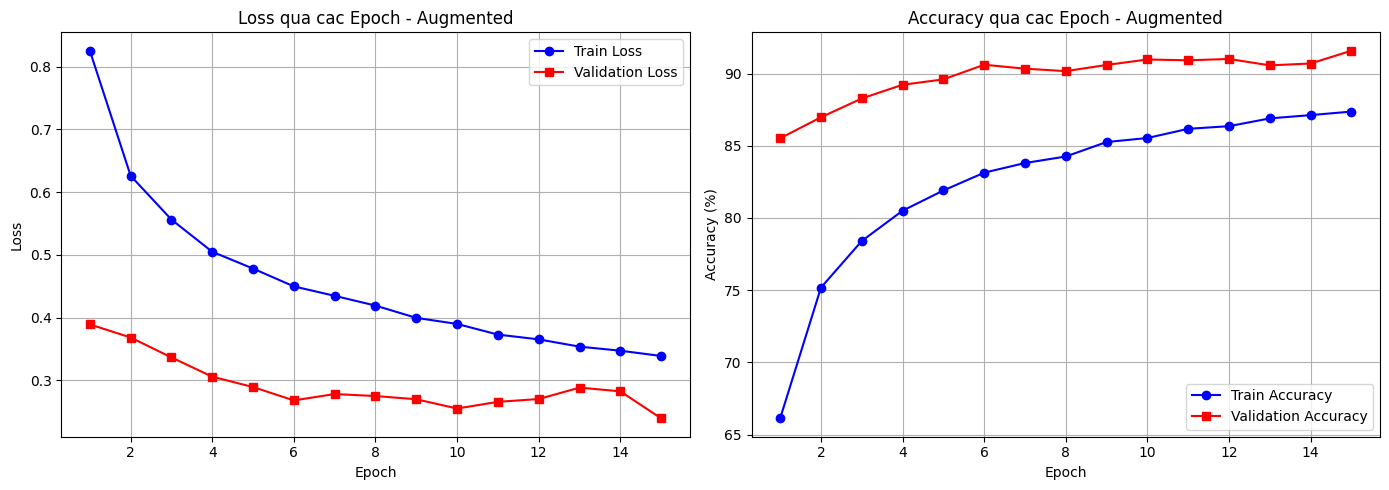

In [12]:
epochs_range = range(1, len(aug_history['train_loss']) + 1)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, aug_history['train_loss'], 'b-o', label='Train Loss')
plt.plot(epochs_range, aug_history['val_loss'], 'r-s', label='Validation Loss')
plt.title('Loss qua cac Epoch - Augmented')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, [a*100 for a in aug_history['train_acc']], 'b-o', label='Train Accuracy')
plt.plot(epochs_range, [a*100 for a in aug_history['val_acc']], 'r-s', label='Validation Accuracy')
plt.title('Accuracy qua cac Epoch - Augmented')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.grid(True)

plt.tight_layout(); plt.show()

## Bước 11: Confusion Matrix trên Test của model tăng cường

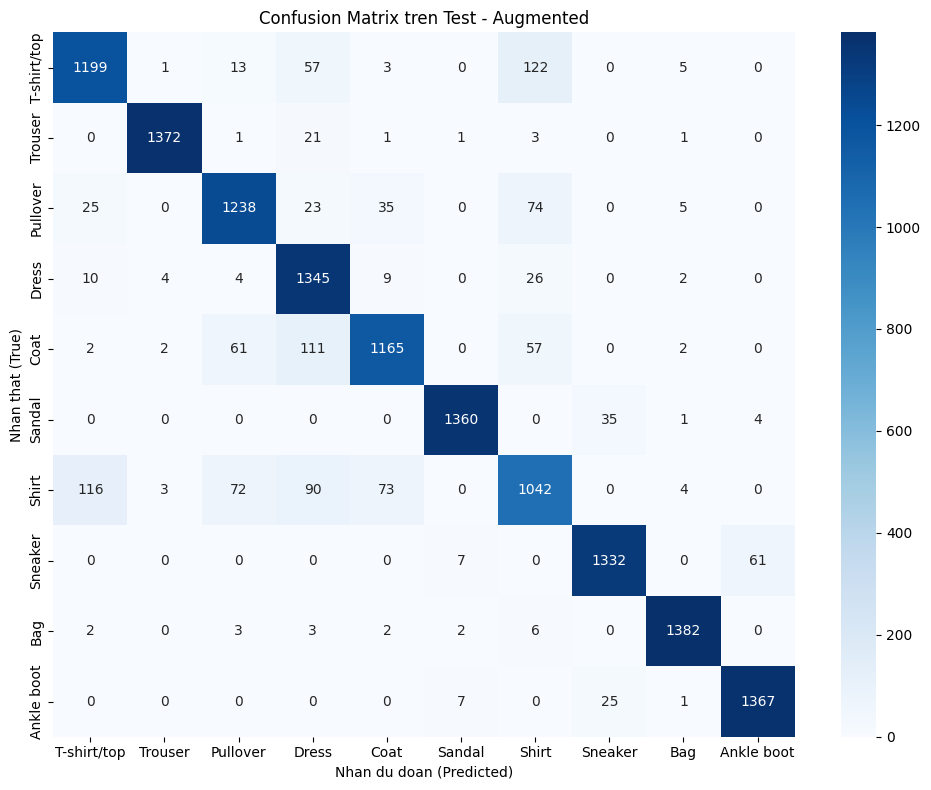

In [13]:
cm = confusion_matrix(y_true.numpy(), y_pred.numpy(), labels=list(range(10)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix tren Test - Augmented')
plt.xlabel('Nhan du doan (Predicted)')
plt.ylabel('Nhan that (True)')
plt.tight_layout(); plt.show()

In [14]:
# Top 10 cap bi nham nhieu nhat tren Test - de so sanh truc tiep voi s3 baseline
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
pairs = [(cm_off[i, j], class_names[i], class_names[j])
         for i in range(len(class_names))
         for j in range(len(class_names))
         if cm_off[i, j] > 0]
pairs.sort(reverse=True)

print("Top 10 cap bi nham nhieu nhat - Augmented (Nhan that -> Nhan doan):")
for count, t, p in pairs[:10]:
    print(f"  {t:<12} -> {p:<12}: {count} anh")

Top 10 cap bi nham nhieu nhat - Augmented (Nhan that -> Nhan doan):
  T-shirt/top  -> Shirt       : 122 anh
  Shirt        -> T-shirt/top : 116 anh
  Coat         -> Dress       : 111 anh
  Shirt        -> Dress       : 90 anh
  Pullover     -> Shirt       : 74 anh
  Shirt        -> Coat        : 73 anh
  Shirt        -> Pullover    : 72 anh
  Sneaker      -> Ankle boot  : 61 anh
  Coat         -> Pullover    : 61 anh
  T-shirt/top  -> Dress       : 57 anh


## Bước 12: Classification Report (Test) và so sánh Recall lớp khó với baseline

In [15]:
print("Classification Report tren Test - Augmented\n")
print(classification_report(y_true.numpy(), y_pred.numpy(), labels=list(range(10)),
                            target_names=class_names, digits=4, zero_division=0))

# So sanh Recall cac lop kho: baseline vs augmented (deu tren Test, bao cao cuoi cung)
base_rep = classification_report(base_test_true.numpy(), base_test_pred.numpy(), labels=list(range(10)),
                                 target_names=class_names, output_dict=True, zero_division=0)
aug_rep = classification_report(y_true.numpy(), y_pred.numpy(), labels=list(range(10)),
                                target_names=class_names, output_dict=True, zero_division=0)
print("-"*60)
print(f"{'Recall cac lop kho (Test)':<16}{'Baseline':>12}{'Augmented':>12}{'Delta':>10}")
for c in sorted(HARD_CLASSES):
    b = base_rep[class_names[c]]['recall']; a = aug_rep[class_names[c]]['recall']
    print(f"{class_names[c]:<16}{b:>12.4f}{a:>12.4f}{(a-b)*100:>+9.2f}%")

Classification Report tren Test - Augmented

              precision    recall  f1-score   support

 T-shirt/top     0.8855    0.8564    0.8707      1400
     Trouser     0.9928    0.9800    0.9863      1400
    Pullover     0.8894    0.8843    0.8868      1400
       Dress     0.8152    0.9607    0.8820      1400
        Coat     0.9045    0.8321    0.8668      1400
      Sandal     0.9877    0.9714    0.9795      1400
       Shirt     0.7835    0.7443    0.7634      1400
     Sneaker     0.9569    0.9514    0.9542      1400
         Bag     0.9850    0.9871    0.9861      1400
  Ankle boot     0.9546    0.9764    0.9654      1400

    accuracy                         0.9144     14000
   macro avg     0.9155    0.9144    0.9141     14000
weighted avg     0.9155    0.9144    0.9141     14000

------------------------------------------------------------
Recall cac lop kho (Test)    Baseline   Augmented     Delta
T-shirt/top           0.8814      0.8564    -2.50%
Pullover              0.

## Bước 13: Một số ảnh vẫn bị nhận diện nhầm (trên Test)

Tong so anh bi nham: 1198 / 14000 (8.56%)


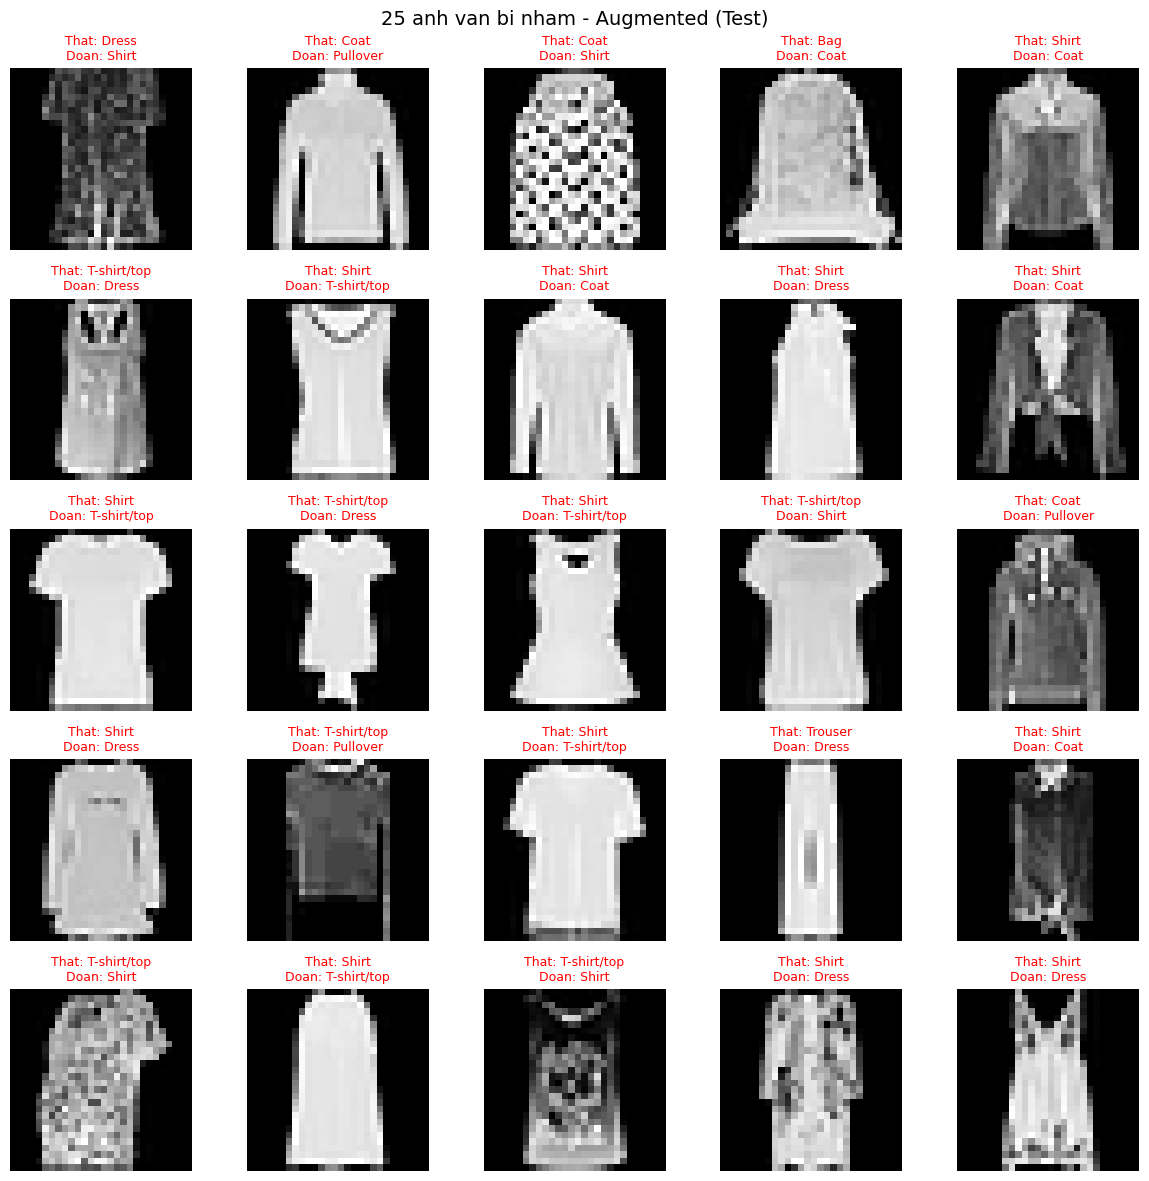

In [16]:
wrong_idx = (y_pred != y_true).nonzero(as_tuple=True)[0]
print(f"Tong so anh bi nham: {len(wrong_idx)} / {len(y_true)} "
      f"({len(wrong_idx)/len(y_true)*100:.2f}%)")

n_show = min(25, len(wrong_idx))
plt.figure(figsize=(12, 12))
for i in range(n_show):
    idx = wrong_idx[i].item()
    img = test_images[idx].squeeze() * 0.5 + 0.5  # bo chuan hoa [-1,1] -> [0,1]
    plt.subplot(5, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f"That: {class_names[y_true[idx]]}\nDoan: {class_names[y_pred[idx]]}",
              color='red', fontsize=9)
plt.suptitle('25 anh van bi nham - Augmented (Test)', fontsize=14)
plt.tight_layout(); plt.show()

## Bước 14: Lưu model
Lưu model nào tốt hơn trên **Validation** (tiêu chí chọn hợp lệ, không dùng Test).

In [17]:
import os
os.makedirs("models", exist_ok=True)

if aug_best_val >= baseline_best_val:
    chosen, chosen_name = aug_model, "augmented"
else:
    chosen, chosen_name = baseline_model, "baseline"

save_path = "models/cnn2d_leakfree.pth"
torch.save(chosen.state_dict(), save_path)
print(f"Model duoc chon theo Validation: {chosen_name}")
print(f"Da luu vao: {save_path}")
print("Tai lai: m = CNN2D(); m.load_state_dict(torch.load('models/cnn2d_leakfree.pth'))")

Model duoc chon theo Validation: baseline
Da luu vao: models/cnn2d_leakfree.pth
Tai lai: m = CNN2D(); m.load_state_dict(torch.load('models/cnn2d_leakfree.pth'))
